### Final Project : Eigen-Value Decomposition (EVD)

#### Envrionment Setup & Data Loading

In [1]:
# Import Library
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# RMSE line plot palette (IEEE-style, colorblind-friendly)
C_RMSE_LAM = "#1F4E79"      # deep navy
C_RMSE_VEC = "#008571"      # muted teal
C_RMSE_THRESH = "#C0392B"   # academic red

# Increase the resolution of the output images
%config InlineBackend.figure_format = 'retina'

# Load Data
data = sio.loadmat("Final11Pattern.mat") # Dictionary
keys = [k for k in data if not k.startswith("__")] # Get the key, ignoring the hidden variables
print(keys)
Matrix = data.get("Matrix")
print(Matrix.shape)

['Matrix']
(3, 3, 11)


#### Create Bit-True Model for EVD by Iterative QR

In [2]:
# Reference Eigen-Value Decomposition
def reference_evd(A):
    return np.linalg.eigh(A)

# Quantization
def quantize(z, b):
    return np.floor(z * 2**b) / 2**b

# Dynamic Range Tracker
class DynamicRangeTracker:

    def __init__(self):
        self.ranges = {}
        self.overflow_count = 0
        self.first_overflow = None

    def _location(self, context, index, shape):
        loc = dict(context)
        if shape:
            loc["element"] = tuple(int(i) for i in np.unravel_index(index, shape))
        return loc

    def record(self, name, values, context):
        values = np.asarray(values, dtype=float)
        flat = values.reshape(-1)
        min_idx = int(np.argmin(flat))
        max_idx = int(np.argmax(flat))
        min_value = float(flat[min_idx])
        max_value = float(flat[max_idx])

        if name not in self.ranges:
            self.ranges[name] = {
                "min": min_value,
                "max": max_value,
                "min_context": self._location(context, min_idx, values.shape),
                "max_context": self._location(context, max_idx, values.shape),
            }
            return

        entry = self.ranges[name]
        if min_value < entry["min"]:
            entry["min"] = min_value
            entry["min_context"] = self._location(context, min_idx, values.shape)
        if max_value > entry["max"]:
            entry["max"] = max_value
            entry["max_context"] = self._location(context, max_idx, values.shape)

    def record_overflow(self, name, raw_values, min_int, max_int, context):
        raw_values = np.asarray(raw_values, dtype=np.int64)
        mask = (raw_values < min_int) | (raw_values > max_int)
        count = int(np.count_nonzero(mask))
        if count == 0:
            return

        self.overflow_count += count
        if self.first_overflow is None:
            flat_idx = int(np.flatnonzero(mask)[0])
            self.first_overflow = {
                "node": name,
                "raw_value": int(raw_values.reshape(-1)[flat_idx]),
                **self._location(context, flat_idx, raw_values.shape),
            }

    def combine(self, names):
        entries = [self.ranges[name] for name in names if name in self.ranges]
        min_entry = min(entries, key=lambda x: x["min"])
        max_entry = max(entries, key=lambda x: x["max"])
        return {
            "min": min_entry["min"],
            "max": max_entry["max"],
            "min_context": min_entry["min_context"],
            "max_context": max_entry["max_context"],
        }

# CORDIC caling factor K (reference)
def cordic_scaling_factor(n_stages):
    K = 1.0
    # K =
    for i in range(n_stages):
        K *= np.sqrt(1.0 + 2.0 ** (-2 * i))
    return K

# CORDIC scaling factor K
def cordic_scale_output(xi, yi, w_xy, cfg):
    if cfg.use_csd:
        x_out = cfg.csd_scale(xi)
        y_out = cfg.csd_scale(yi)
        return x_out, y_out

    k = cordic_scaling_factor(cfg.n_stages)
    x_out = cfg.q(xi / (2**w_xy) / k, "cordic_scaled_output")
    y_out = cfg.q(yi / (2**w_xy) / k, "cordic_scaled_output")
    return x_out, y_out

# Configuration Quantization Setting Class
class EVDConfig:

    def __init__(
        self,
        b=16,               # fractional bits for quantize
        n_stages=16,        # CORDIC micro-rotation stages
        mu=0.0,             # fixed shift
        max_iter=8,         # QR iterations
        total_bits=None,    # signed datapath width
        tracker=None,       # optional range tracker
        use_csd=False,      # RTL CSD gain compensation
    ):
        self.b = b
        self.n_stages = n_stages
        self.mu = mu
        self.max_iter = max_iter
        self.total_bits = total_bits
        self.tracker = tracker
        self.use_csd = use_csd
        self.context = {}
        self.scale = 1 << self.b

    def set_context(self, **kwargs):
        self.context.update(kwargs)

    def track(self, name, values):
        if self.tracker is not None:
            self.tracker.record(name, values, self.context)

    def wrap(self, values, name):
        values = np.asarray(values, dtype=np.int64)
        self.track(f"{name}_raw", values / self.scale)

        if self.total_bits is not None:
            min_int = -(1 << (self.total_bits - 1))
            max_int = (1 << (self.total_bits - 1)) - 1
            if self.tracker is not None:
                self.tracker.record_overflow(
                    name, values, min_int, max_int, self.context
                )
            modulus = 1 << self.total_bits
            values = (values + (modulus >> 1)) % modulus - (modulus >> 1)

        self.track(name, values / self.scale)
        return int(values) if values.ndim == 0 else values

    # Define the quantization function
    def q(self, z, name="matrix_register"):
        if self.total_bits is None:
            result = quantize(z, self.b)
            self.track(name, result)
            return result

        fixed = np.floor(np.asarray(z) * self.scale).astype(np.int64)
        fixed = self.wrap(fixed, name)
        result = np.asarray(fixed) / self.scale
        return float(result) if result.ndim == 0 else result

    def csd_scale(self, value):
        scale_a = self.wrap((value >> 1) + (value >> 3), "cordic_scale_a")
        scale_b = self.wrap((value >> 6) + (value >> 9), "cordic_scale_b")
        output = self.wrap(scale_a - scale_b, "cordic_scaled_output")
        return output / self.scale

# CORDIC Vectoring Mode (records dir_bits for rotation replay)
def cordic_vectoring(x, y, cfg):
    w_xy = cfg.b
    dir_bits = []
    pre_flip = x < 0
    cfg.set_context(mode="vectoring", stage=None)
    cfg.track("cordic_input", [x, y])

    if cfg.total_bits is None:
        if pre_flip:
            x, y = -x, -y
        xi = int(np.floor(x * 2**w_xy))
        yi = int(np.floor(y * 2**w_xy))
        cfg.track("cordic_preprocess", [xi / cfg.scale, yi / cfg.scale])
    else:
        xi = int(np.floor(x * cfg.scale))
        yi = int(np.floor(y * cfg.scale))
        xi = cfg.wrap(-xi if pre_flip else xi, "cordic_preprocess")
        yi = cfg.wrap(-yi if pre_flip else yi, "cordic_preprocess")

    for i in range(cfg.n_stages):
        cfg.set_context(stage=i)
        d = 1 if yi >= 0 else 0
        dir_bits.append(d)
        dX = yi >> i
        dY = xi >> i
        if d:
            xi = cfg.wrap(xi + dX, "cordic_internal")
            yi = cfg.wrap(yi - dY, "cordic_internal")
        else:
            xi = cfg.wrap(xi - dX, "cordic_internal")
            yi = cfg.wrap(yi + dY, "cordic_internal")

    x_out, y_out = cordic_scale_output(xi, yi, w_xy, cfg)
    if cfg.use_csd:
        y_out = 0.0
    return x_out, y_out, {"bits": dir_bits, "pre_flip": pre_flip}

# CORDIC Rotation Mode (replay dir_bits from vectoring)
def cordic_rotation(x, y, dir_info, cfg):
    w_xy = cfg.b
    cfg.set_context(mode="rotation", stage=None)
    cfg.track("cordic_input", [x, y])

    if cfg.total_bits is None:
        if dir_info["pre_flip"]:
            x, y = -x, -y
        xi = int(np.floor(x * 2**w_xy))
        yi = int(np.floor(y * 2**w_xy))
        cfg.track("cordic_preprocess", [xi / cfg.scale, yi / cfg.scale])
    else:
        xi = int(np.floor(x * cfg.scale))
        yi = int(np.floor(y * cfg.scale))
        pre_flip = dir_info["pre_flip"]
        xi = cfg.wrap(-xi if pre_flip else xi, "cordic_preprocess")
        yi = cfg.wrap(-yi if pre_flip else yi, "cordic_preprocess")

    for i, d in enumerate(dir_info["bits"]):
        cfg.set_context(stage=i)
        dX = yi >> i
        dY = xi >> i
        if d:
            xi = cfg.wrap(xi + dX, "cordic_internal")
            yi = cfg.wrap(yi - dY, "cordic_internal")
        else:
            xi = cfg.wrap(xi - dX, "cordic_internal")
            yi = cfg.wrap(yi + dY, "cordic_internal")

    x_out, y_out = cordic_scale_output(xi, yi, w_xy, cfg)
    return x_out, y_out

# Apply 1 Givens Rotation to R
def apply_givens_rows(M, p, q, col, cfg):
    cfg.set_context(givens=f"G{p}{q}")
    M = np.array(M, dtype=float, copy=True) # make M copy
    # extract the two rows to be rotated and make copies -> quantization
    rp = cfg.q(M[p, :].copy(), "matrix_r")
    rq = cfg.q(M[q, :].copy(), "matrix_r")
    # vectoring: zero pivot and record dir_bits
    rp[col], rq[col], dir_info = cordic_vectoring(rp[col], rq[col], cfg)
    # rotation: replay dir_bits on remaining columns
    for m in range(col + 1, M.shape[1]):
        rp[m], rq[m] = cordic_rotation(rp[m], rq[m], dir_info, cfg)
    # update the matrix
    M[p, :] = rp
    M[q, :] = rq
    return M, dir_info


# Givens Rotation Order Setting [row1, row2, col]
GIVENS_PAIRS = [(0, 1, 0), (0, 2, 0), (1, 2, 1)]

# QR Decomposition, getting complete R
def qrd_phase2(T, cfg):
    cfg.set_context(phase="QRD", givens=None, mode=None, stage=None)
    R = cfg.q(np.array(T, dtype=float, copy=True), "matrix_r")
    dir_infos = []
    for p, q, col in GIVENS_PAIRS:
        R, dir_info = apply_givens_rows(R, p, q, col, cfg)
        dir_infos.append(dir_info)
    return cfg.q(R, "matrix_r"), dir_infos

# Givens Rotation using dir_bits from QR Decomposition
def qrd_rotation_pass(M, dir_infos, cfg, columns=False, phase=None):
    cfg.set_context(phase=phase, givens=None, mode=None, stage=None)
    M = np.array(M, dtype=float, copy=True)
    for (p, q, _col), dir_info in zip(GIVENS_PAIRS, dir_infos):
        cfg.set_context(givens=f"G{p}{q}")
        if columns:
            cp = cfg.q(M[:, p].copy(), "eigenvector_u")
            cq = cfg.q(M[:, q].copy(), "eigenvector_u")
            for i in range(M.shape[0]):
                cp[i], cq[i] = cordic_rotation(cp[i], cq[i], dir_info, cfg)
            M[:, p] = cp
            M[:, q] = cq
            cfg.track("eigenvector_u", M)
        else:
            rp = cfg.q(M[p, :].copy(), "matrix_t")
            rq = cfg.q(M[q, :].copy(), "matrix_t")
            for m in range(M.shape[1]):
                rp[m], rq[m] = cordic_rotation(rp[m], rq[m], dir_info, cfg)
            M[p, :] = rp
            M[q, :] = rq
            cfg.track("matrix_t", M)
    output_name = "eigenvector_u" if columns else "matrix_t"
    return cfg.q(M, output_name)


# Matrix Transpose
def matrix_transpose(M, cfg):
    return cfg.q(np.array(M.T, dtype=float, copy=True), "matrix_r")


# Eigen-Value Decomposition by Iterative QR Algorithm
def iterative_qr_evd(A, cfg):
    n = A.shape[0]
    cfg.set_context(iteration=0, phase="input", givens=None, mode=None, stage=None)
    T = cfg.q(np.array(A, dtype=float), "input_quantized") # initial T = q(A)
    U = cfg.q(np.eye(n), "eigenvector_u") # Initialize: U = q(I)
    iters = 0
    I = np.eye(n)

    for iteration in range(cfg.max_iter):
        iters += 1
        cfg.set_context(iteration=iteration + 1, phase="shift")
        T_shifted = cfg.q(T - cfg.mu * I, "matrix_t") # Hessenberg Reduction & Shift
        R, dir_infos = qrd_phase2(T_shifted, cfg) # QR Decomposition, Get R
        RT = matrix_transpose(R, cfg) # Transpose R
        T_rot = qrd_rotation_pass(RT, dir_infos, cfg, phase="T update")
        T = cfg.q(T_rot + cfg.mu * I, "matrix_t") # T = (RQ)^T
        U = qrd_rotation_pass(U, dir_infos, cfg, columns=True, phase="U update") # U = UQ

    cfg.set_context(phase="output", givens=None, mode=None, stage=None)
    cfg.track("eigenvalue_output", np.diag(T))
    cfg.track("eigenvector_output", U)
    lam = np.diag(T) # Get Eigenvalues
    return lam, U, T, iters


# Use Reference to Align Eigenvector Order
def align_eigenpairs(lam_ref, V_ref, lam_hat, V_hat):
    idx = np.argsort(lam_hat)
    lam_hat = lam_hat[idx]
    V_hat = V_hat[:, idx]
    for i in range(len(lam_ref)):
        if np.dot(V_ref[:, i], V_hat[:, i]) < 0:
            V_hat[:, i] *= -1
    return lam_hat, V_hat


# RMSE of Eigenvalues
def rmse_eigenvalues(lam_ref, lam_hat):
    return float(np.sqrt(np.mean((lam_ref - lam_hat) ** 2)))


# RMSE of Eigenvectors
def rmse_eigenvectors(V_ref, V_hat):
    sq = sum(
        np.linalg.norm(V_ref[:, i] - V_hat[:, i]) ** 2
        for i in range(V_ref.shape[1])
    )
    return float(np.sqrt(sq / 9))


def evaluate_evd(A, cfg):
    lam_ref, V_ref = reference_evd(A)
    lam_hat, V_hat, _, n_iter = iterative_qr_evd(A, cfg)
    lam_hat, V_hat = align_eigenpairs(lam_ref, V_ref, lam_hat, V_hat)
    return {
        "rmse_lam": rmse_eigenvalues(lam_ref, lam_hat),
        "rmse_vec": rmse_eigenvectors(V_ref, V_hat),
        "n_iter": n_iter,
    }


def evaluate_all_patterns(Matrix, cfg):
    n_sets = Matrix.shape[2]
    rmse_lam = np.zeros(n_sets)
    rmse_vec = np.zeros(n_sets)
    for s in range(n_sets):
        cfg.set_context(pattern=s + 1)
        r = evaluate_evd(Matrix[:, :, s], cfg)
        rmse_lam[s] = r["rmse_lam"]
        rmse_vec[s] = r["rmse_vec"]
    return rmse_lam, rmse_vec


#### RMSE verus wordlength & CORDIC stages

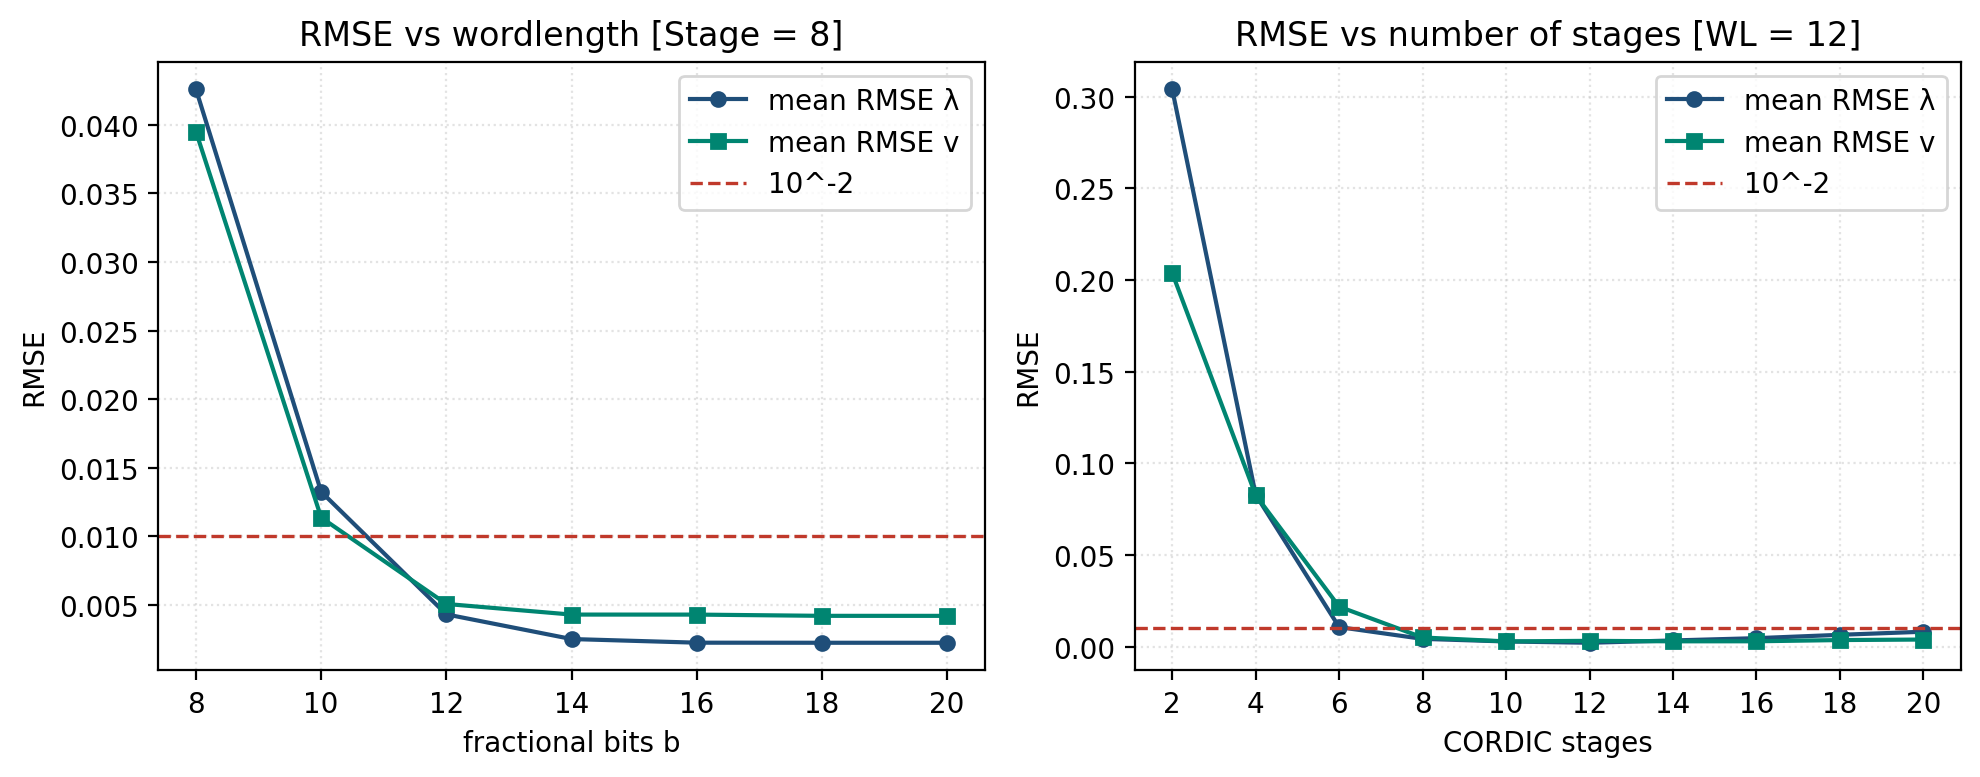

In [3]:
## RMSE verus wordlength & CORDIC stages
def sweep_wordlength(Matrix, b_list, n_stages):
    mean_lam, mean_vec, max_lam, max_vec = [], [], [], []
    for b in b_list:
        cfg = EVDConfig(b, n_stages, 0.0, 8)
        rl, rv = evaluate_all_patterns(Matrix, cfg)
        mean_lam.append(rl.mean())
        mean_vec.append(rv.mean())
        max_lam.append(rl.max())
        max_vec.append(rv.max())
    return np.array(mean_lam), np.array(mean_vec), np.array(max_lam), np.array(max_vec)

# RMSE verus CORDIC stages
def sweep_stages(Matrix, stage_list, b):
    mean_lam, mean_vec, max_lam, max_vec = [], [], [], []
    for n in stage_list:
        cfg = EVDConfig(b, n, 0.0, 8)
        rl, rv = evaluate_all_patterns(Matrix, cfg)
        mean_lam.append(rl.mean())
        mean_vec.append(rv.mean())
        max_lam.append(rl.max())
        max_vec.append(rv.max())
    return np.array(mean_lam), np.array(mean_vec), np.array(max_lam), np.array(max_vec)


# Example sweeps (adjust ranges as needed)
B_LIST = [8, 10, 12, 14, 16, 18, 20]
STAGE_LIST = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

# Draw the Figure
ml, mv, xl, xv = sweep_wordlength(Matrix, B_LIST, n_stages=8)
sl, sv, _, _ = sweep_stages(Matrix, STAGE_LIST, b=12)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(B_LIST, ml, "o-", color=C_RMSE_LAM, label="mean RMSE λ", linewidth=1.5, markersize=5)
axes[0].plot(B_LIST, mv, "s-", color=C_RMSE_VEC, label="mean RMSE v", linewidth=1.5, markersize=5)
axes[0].axhline(1e-2, color=C_RMSE_THRESH, ls="--", linewidth=1.2, label="10^-2")
axes[0].set_xlabel("fractional bits b")
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE vs wordlength [Stage = 8]")
axes[0].set_xticks(B_LIST)
axes[0].legend()
axes[0].grid(True, alpha=0.35, linestyle=":")

axes[1].plot(STAGE_LIST, sl, "o-", color=C_RMSE_LAM, label="mean RMSE λ", linewidth=1.5, markersize=5)
axes[1].plot(STAGE_LIST, sv, "s-", color=C_RMSE_VEC, label="mean RMSE v", linewidth=1.5, markersize=5)
axes[1].axhline(1e-2, color=C_RMSE_THRESH, ls="--", linewidth=1.2, label="10^-2")
axes[1].set_xlabel("CORDIC stages")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE vs number of stages [WL = 12]")
axes[1].set_xticks(STAGE_LIST)
axes[1].legend()
axes[1].grid(True, alpha=0.35, linestyle=":")
plt.tight_layout()
plt.show()

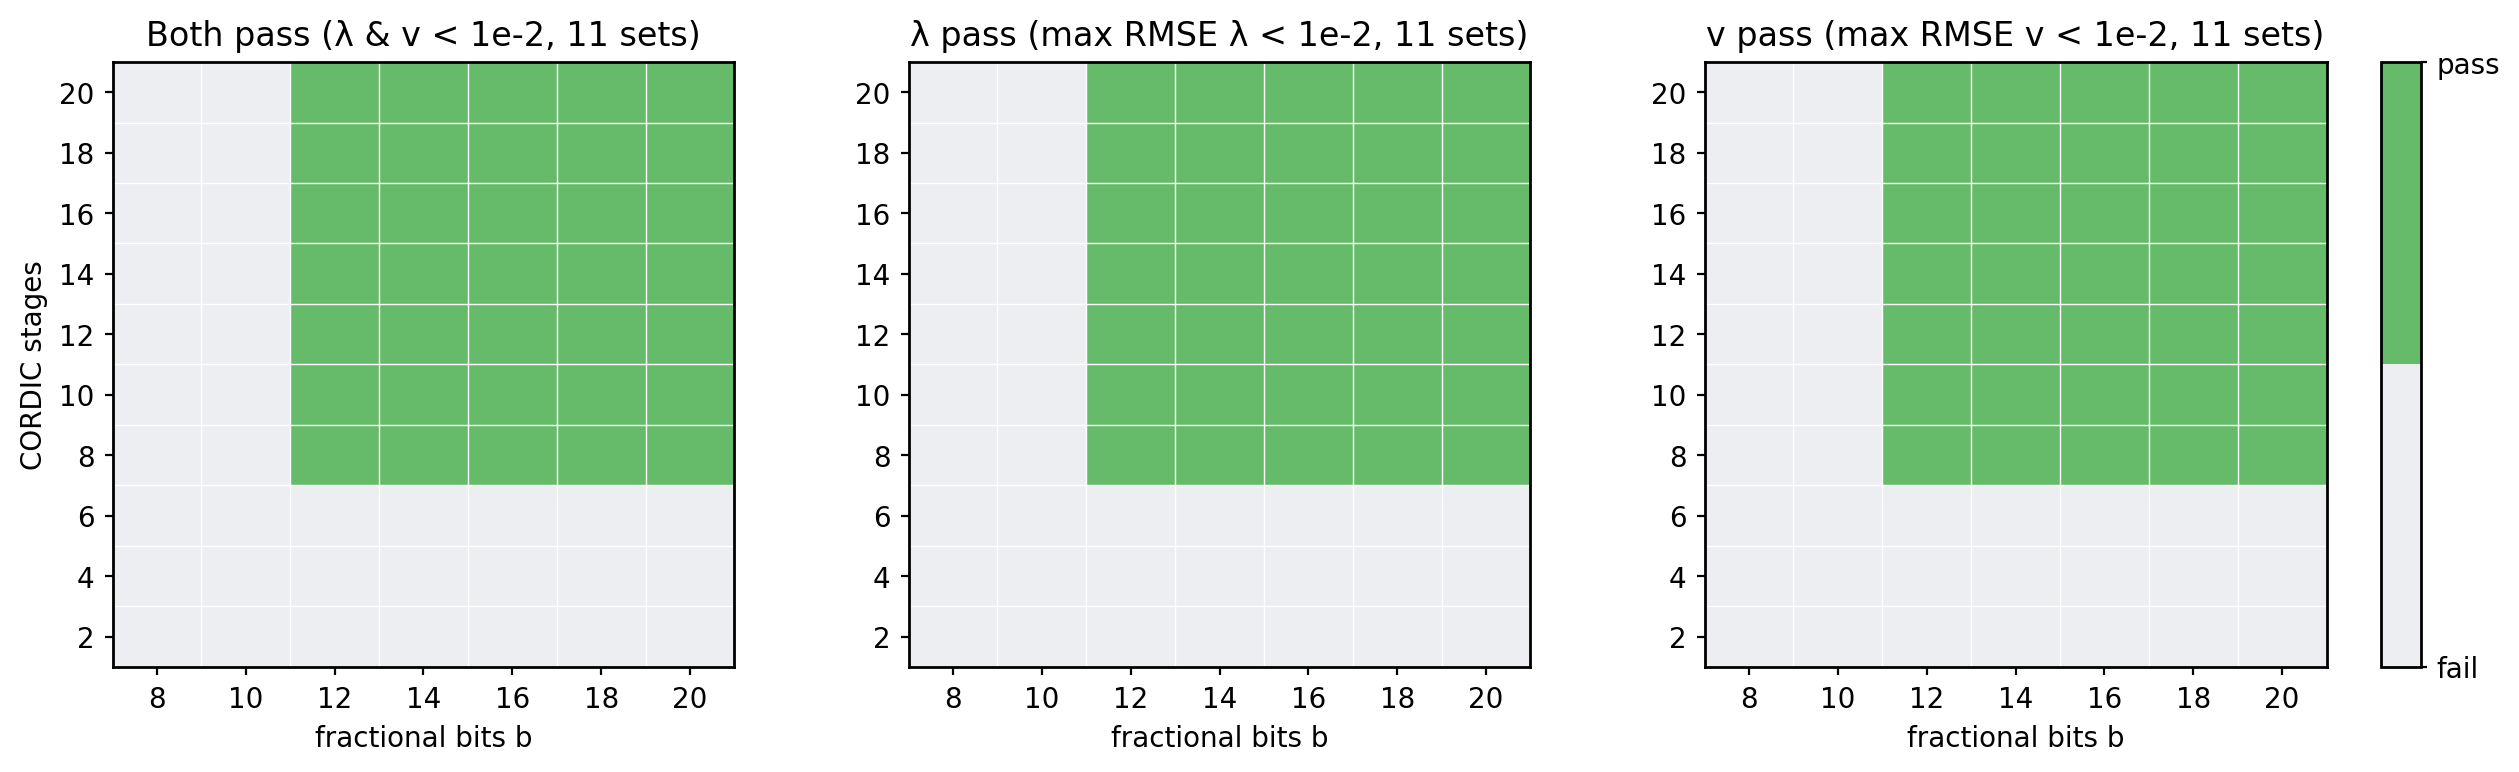

In [4]:
# 2D sweep for min-parameter search
RMSE_THRESH = 1e-2

def sweep_grid(Matrix, b_list, stage_list, max_iter=7):
    nb, ns = len(b_list), len(stage_list)
    max_lam = np.zeros((ns, nb))
    max_vec = np.zeros((ns, nb))
    pass_all = np.zeros((ns, nb), dtype=bool)

    for i, n in enumerate(stage_list):
        for j, b in enumerate(b_list):
            cfg = EVDConfig(b, n, 0.0, max_iter)
            rl, rv = evaluate_all_patterns(Matrix, cfg)
            max_lam[i, j] = rl.max()
            max_vec[i, j] = rv.max()
            pass_all[i, j] = (rl < RMSE_THRESH).all() and (rv < RMSE_THRESH).all()
    return max_lam, max_vec, pass_all


B_GRID = [8, 10, 12, 14, 16, 18, 20]
STAGE_GRID = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

max_lam_2d, max_vec_2d, pass_2d = sweep_grid(Matrix, B_GRID, STAGE_GRID, max_iter=7)
pass_lam_2d = max_lam_2d < RMSE_THRESH
pass_vec_2d = max_vec_2d < RMSE_THRESH


CMAP_PASS = ListedColormap(["#ECEEF1", "#66BB6A"])

def plot_pass_map(ax, pass_map, title, show_ylabel=True):
    im = ax.imshow(
        pass_map.astype(float),
        origin="lower",
        aspect="auto",
        cmap=CMAP_PASS,
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    ax.set_xticks(np.arange(-0.5, len(B_GRID), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(STAGE_GRID), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.5, linestyle="-")
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.set_xticks(range(len(B_GRID)), B_GRID)
    ax.set_yticks(range(len(STAGE_GRID)), STAGE_GRID)
    ax.set_xlabel("fractional bits b")
    if show_ylabel:
        ax.set_ylabel("CORDIC stages")
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=True)
    ax.set_title(title)

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color("black")
    ax.tick_params(width=0.8, length=3, colors="black")
    return im


fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

ims = [
    plot_pass_map(axes[0], pass_2d, "Both pass (λ & v < 1e-2, 11 sets)"),
    plot_pass_map(axes[1], pass_lam_2d, "λ pass (max RMSE λ < 1e-2, 11 sets)", show_ylabel=False),
    plot_pass_map(axes[2], pass_vec_2d, "v pass (max RMSE v < 1e-2, 11 sets)", show_ylabel=False),
]

fig.subplots_adjust(left=0.08, right=0.90, bottom=0.16, top=0.88, wspace=0.28)
cax = fig.add_axes([0.92, 0.16, 0.015, 0.72])
cbar = fig.colorbar(ims[0], cax=cax, ticks=[0, 1])
cbar.ax.set_yticklabels(["fail", "pass"])
cbar.outline.set_linewidth(1.0)
cbar.outline.set_edgecolor("black")
cbar.ax.tick_params(width=0.8, length=2, colors="black")

plt.show()

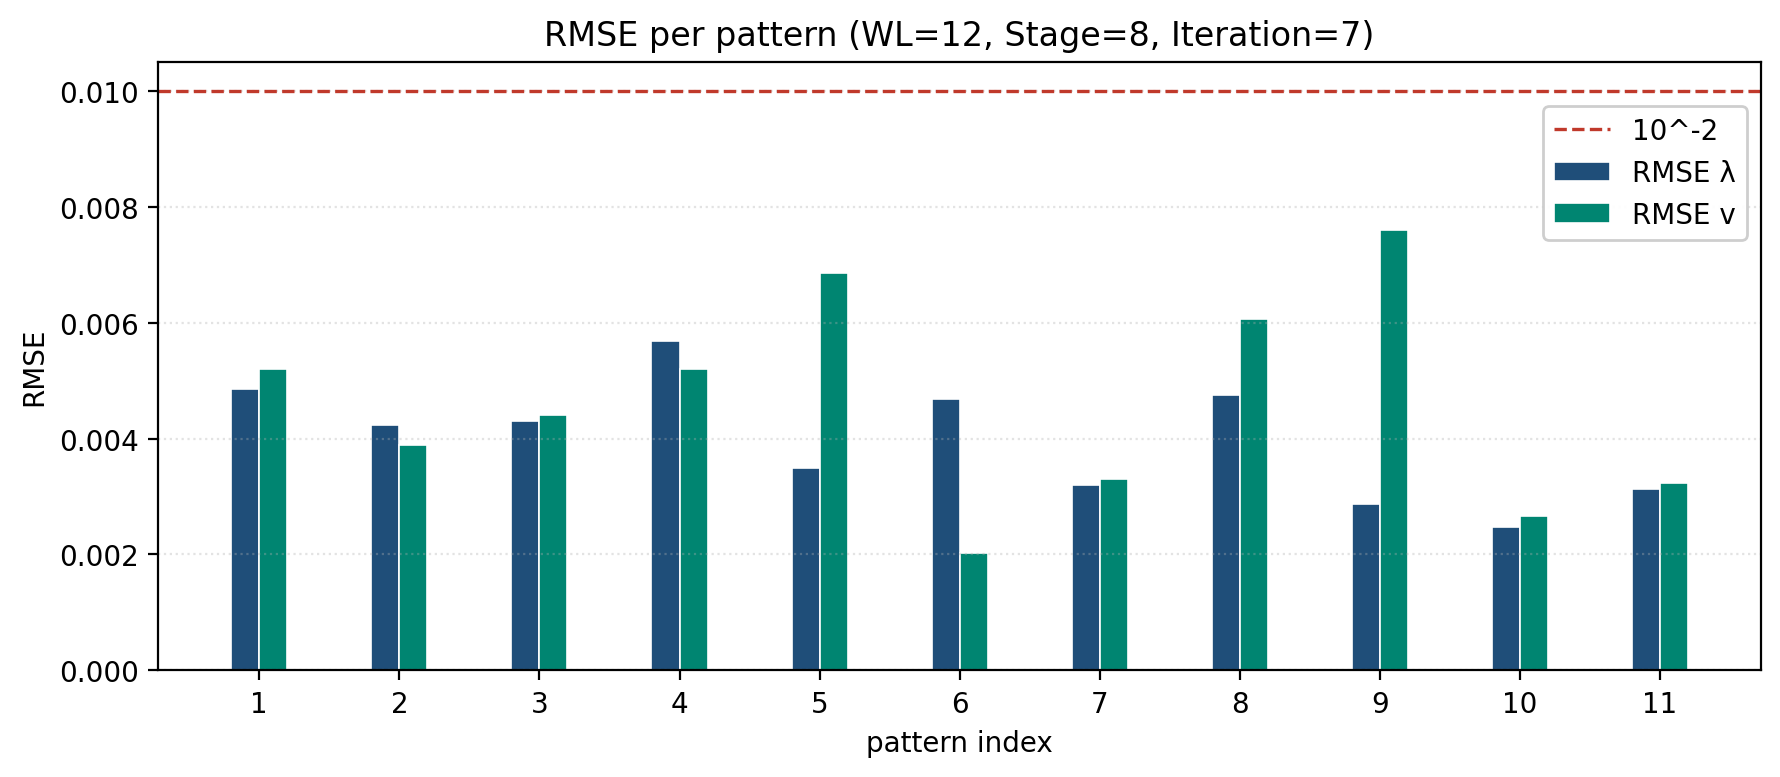

In [5]:
# Evaluate 11 patterns (Requirement 1: RMSE λ and v < 1e-2)
B = 12
N_STAGES = 8
MAX_ITER = 7
RMSE_THRESH = 1e-2

cfg = EVDConfig(B, N_STAGES, 0.0, MAX_ITER)
rmse_lam, rmse_vec = evaluate_all_patterns(Matrix, cfg)

idx = np.arange(1, Matrix.shape[2] + 1)
bar_w = 0.2
x = np.arange(Matrix.shape[2])

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - bar_w / 2, rmse_lam, bar_w, color=C_RMSE_LAM, label="RMSE λ", edgecolor="white", linewidth=0.6)
ax.bar(x + bar_w / 2, rmse_vec, bar_w, color=C_RMSE_VEC, label="RMSE v", edgecolor="white", linewidth=0.6)
ax.axhline(RMSE_THRESH, color=C_RMSE_THRESH, ls="--", linewidth=1.2, label="10^-2")
ax.set_xlabel("pattern index")
ax.set_ylabel("RMSE")
ax.set_title(f"RMSE per pattern (WL={B}, Stage={N_STAGES}, Iteration={MAX_ITER})")
ax.set_xticks(x, idx)
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.95), framealpha=0.95)
ax.grid(True, axis="y", alpha=0.35, linestyle=":")
plt.tight_layout()
plt.show()

#### Determine Hardware Configuration

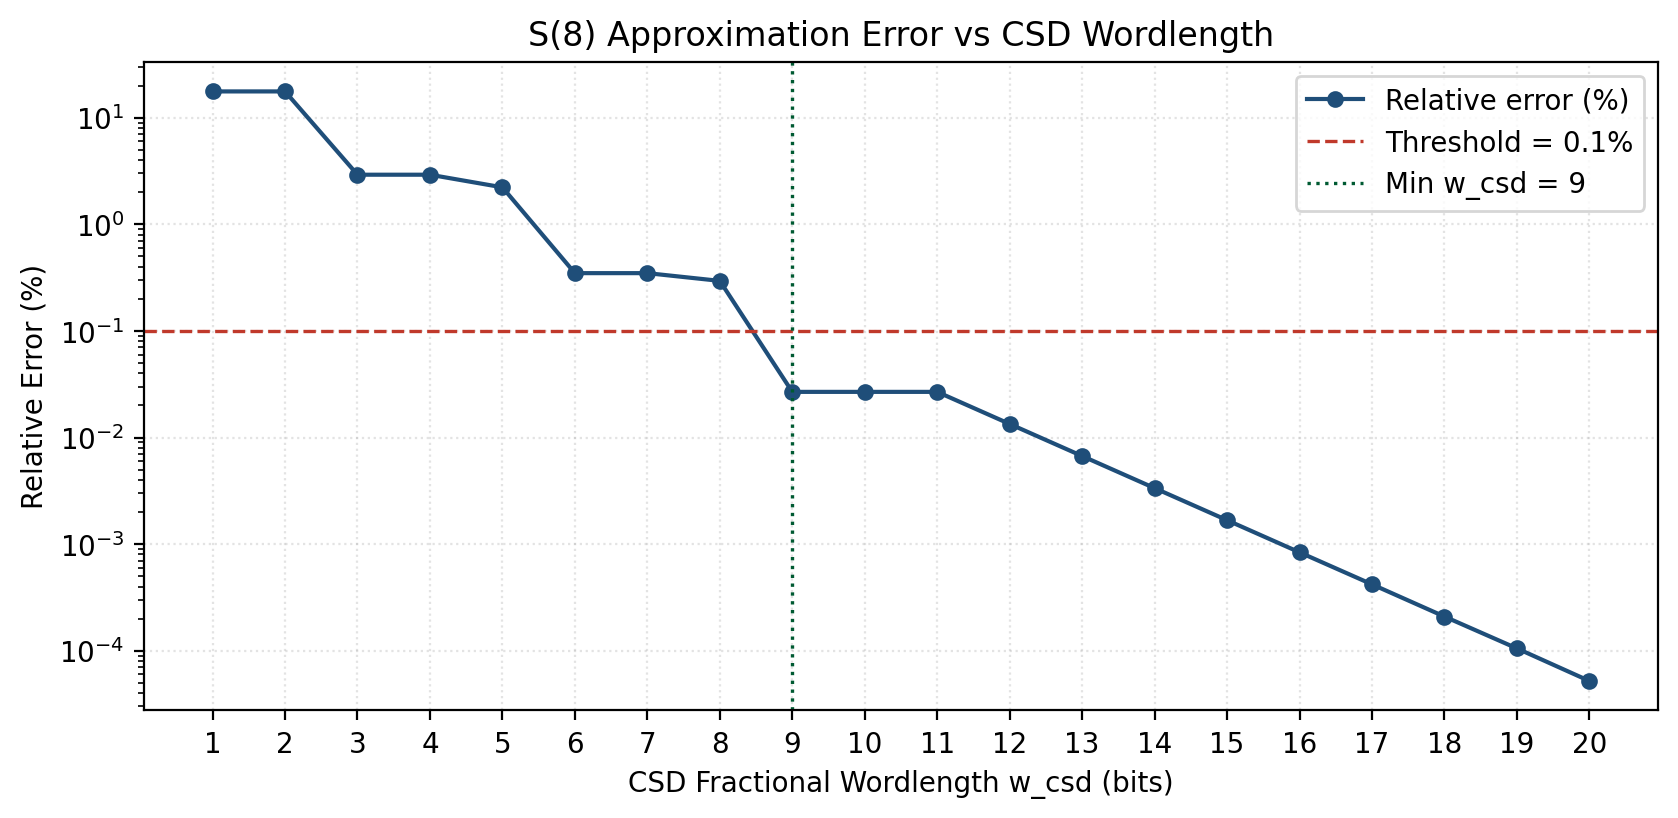

=== Min CSD (w_csd=9, rel error < 0.1%) ===
S_true     = 0.6072591123
S_csd      = 0.6074218750
Rel error  = 0.0268028%
Fixed int  = 311  (= round(S_true * 2^9))
CSD binary = 0.100110111  (Q0.9)
Formula    = 2^-1+2^-3-2^-6-2^-9
pos shifts = (1, 3)
neg shifts = (6, 9)
Adders     = 3
Shift-and-add:
  + (X >> 1)
  + (X >> 3)
  - (X >> 6)
  - (X >> 9)


In [6]:
# CSD gain compensation: (1/K) approximation error vs w_csd
REL_ERR_THRESH_PCT = 0.1
W_CSD_LIST = np.arange(1, 21)
S_true = 1.0 / cordic_scaling_factor(N_STAGES)

# CSD Transformation
def to_csd(value, n_frac_bits):
    n = int(np.round(value * 2**n_frac_bits))
    digits = {}
    pos = -n_frac_bits
    while n != 0:
        if n & 1:
            d = -1 if (n & 3) == 3 else 1
            digits[pos] = d
            n -= d
        n >>= 1
        pos += 1
    csd_val = sum(d * 2.0**p for p, d in digits.items())
    return csd_val, digits

# Sweep
w_vals, rel_errs, best = [], [], None
for w in W_CSD_LIST:
    w = int(w)
    s_csd, digits = to_csd(S_true, w)
    pos = tuple(sorted(-p for p, d in digits.items() if d > 0))
    neg = tuple(sorted(-p for p, d in digits.items() if d < 0))
    err = abs(S_true - s_csd) / S_true * 100.0
    w_vals.append(w)
    rel_errs.append(err)
    if err < REL_ERR_THRESH_PCT and best is None:
        best = {"w": w, "pos": pos, "neg": neg, "s_csd": s_csd, "err": err}

# Draw the figure
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(w_vals, rel_errs, "o-", color=C_RMSE_LAM, label="Relative error (%)", linewidth=1.5, markersize=5)
ax.axhline(REL_ERR_THRESH_PCT, color=C_RMSE_THRESH, ls="--", linewidth=1.2, label=f"Threshold = {REL_ERR_THRESH_PCT:g}%")
if best:
    ax.axvline(best["w"], color="#005a32", ls=":", linewidth=1.2, label=f"Min w_csd = {best['w']}")
ax.set_xlabel("CSD Fractional Wordlength w_csd (bits)")
ax.set_ylabel("Relative Error (%)")
ax.set_yscale("log")
ax.set_title(f"S({N_STAGES}) Approximation Error vs CSD Wordlength")
ax.set_xticks(w_vals)
ax.grid(True, alpha=0.35, linestyle=":")
ax.legend()
plt.tight_layout()
plt.show()

if best:
    w, pos, neg = best["w"], best["pos"], best["neg"]
    n_fixed = int(np.round(S_true * 2**w))
    formula = "+".join(f"2^-{s}" for s in pos) + ("-" + "-".join(f"2^-{s}" for s in neg) if neg else "")
    print(f"=== Min CSD (w_csd={w}, rel error < {REL_ERR_THRESH_PCT:g}%) ===")
    print(f"S_true     = {S_true:.10f}")
    print(f"S_csd      = {best['s_csd']:.10f}")
    print(f"Rel error  = {best['err']:.6g}%")
    print(f"Fixed int  = {n_fixed}  (= round(S_true * 2^{w}))")
    print(f"CSD binary = 0.{n_fixed:0{w}b}  (Q0.{w})")
    print(f"Formula    = {formula}")
    print(f"pos shifts = {pos}")
    print(f"neg shifts = {neg}")
    print(f"Adders     = {len(pos) + len(neg) - 1}")
    print("Shift-and-add:")
    for s in pos:
        print(f"  + (X >> {s})")
    for s in neg:
        print(f"  - (X >> {s})")
else:
    print(f"No w_csd in [{W_CSD_LIST[0]}, {W_CSD_LIST[-1]}] achieves rel error < {REL_ERR_THRESH_PCT:g}%")

#### Integer Bit-Width Analysis

The main sweep keeps the original ideal `1/K` model to isolate integer-width overflow. The RTL CSD scaling result is reported separately.

,Node,Min,Max,Max abs,Integer bits,Q format,Total bits,Worst-case location
0,Quantized input,-2.394043,10.239014,10.239014,4,Q4.12,17,"pattern=11, iteration=0, phase=input, element=..."
1,Matrix T/R,-5.116699,10.587402,10.587402,4,Q4.12,17,"pattern=11, iteration=4, phase=T update, given..."
2,Eigenvector U,-0.980469,1.000000,1.000000,1,Q1.12,14,"pattern=1, iteration=0, phase=input, element=(..."
3,CORDIC input,-5.116699,10.587402,10.587402,4,Q4.12,17,"pattern=11, iteration=4, phase=T update, given..."
4,CORDIC internal,-10.586182,17.434814,17.434814,5,Q5.12,18,"pattern=11, iteration=4, phase=T update, given..."
5,Scaled output,-5.116699,10.587402,10.587402,4,Q4.12,17,"pattern=11, iteration=4, phase=T update, given..."


,Total bits,Q format,Overflow count,Max eigenvalue RMSE,Max eigenvector RMSE,Passing patterns,Status,First overflow
0,15,Q2.12,119,5.810924,0.783096,0,FAIL,"pattern=1, iteration=0, phase=input, element=(..."
1,16,Q3.12,23,7.994243,0.806298,5,FAIL,"pattern=1, iteration=1, phase=QRD, givens=G01,..."
2,17,Q4.12,1,6.913700,0.764008,10,FAIL,"pattern=11, iteration=1, phase=QRD, givens=G01..."
3,18,Q5.12,0,0.005687,0.007598,11,PASS,-
4,19,Q6.12,0,0.005687,0.007598,11,PASS,-


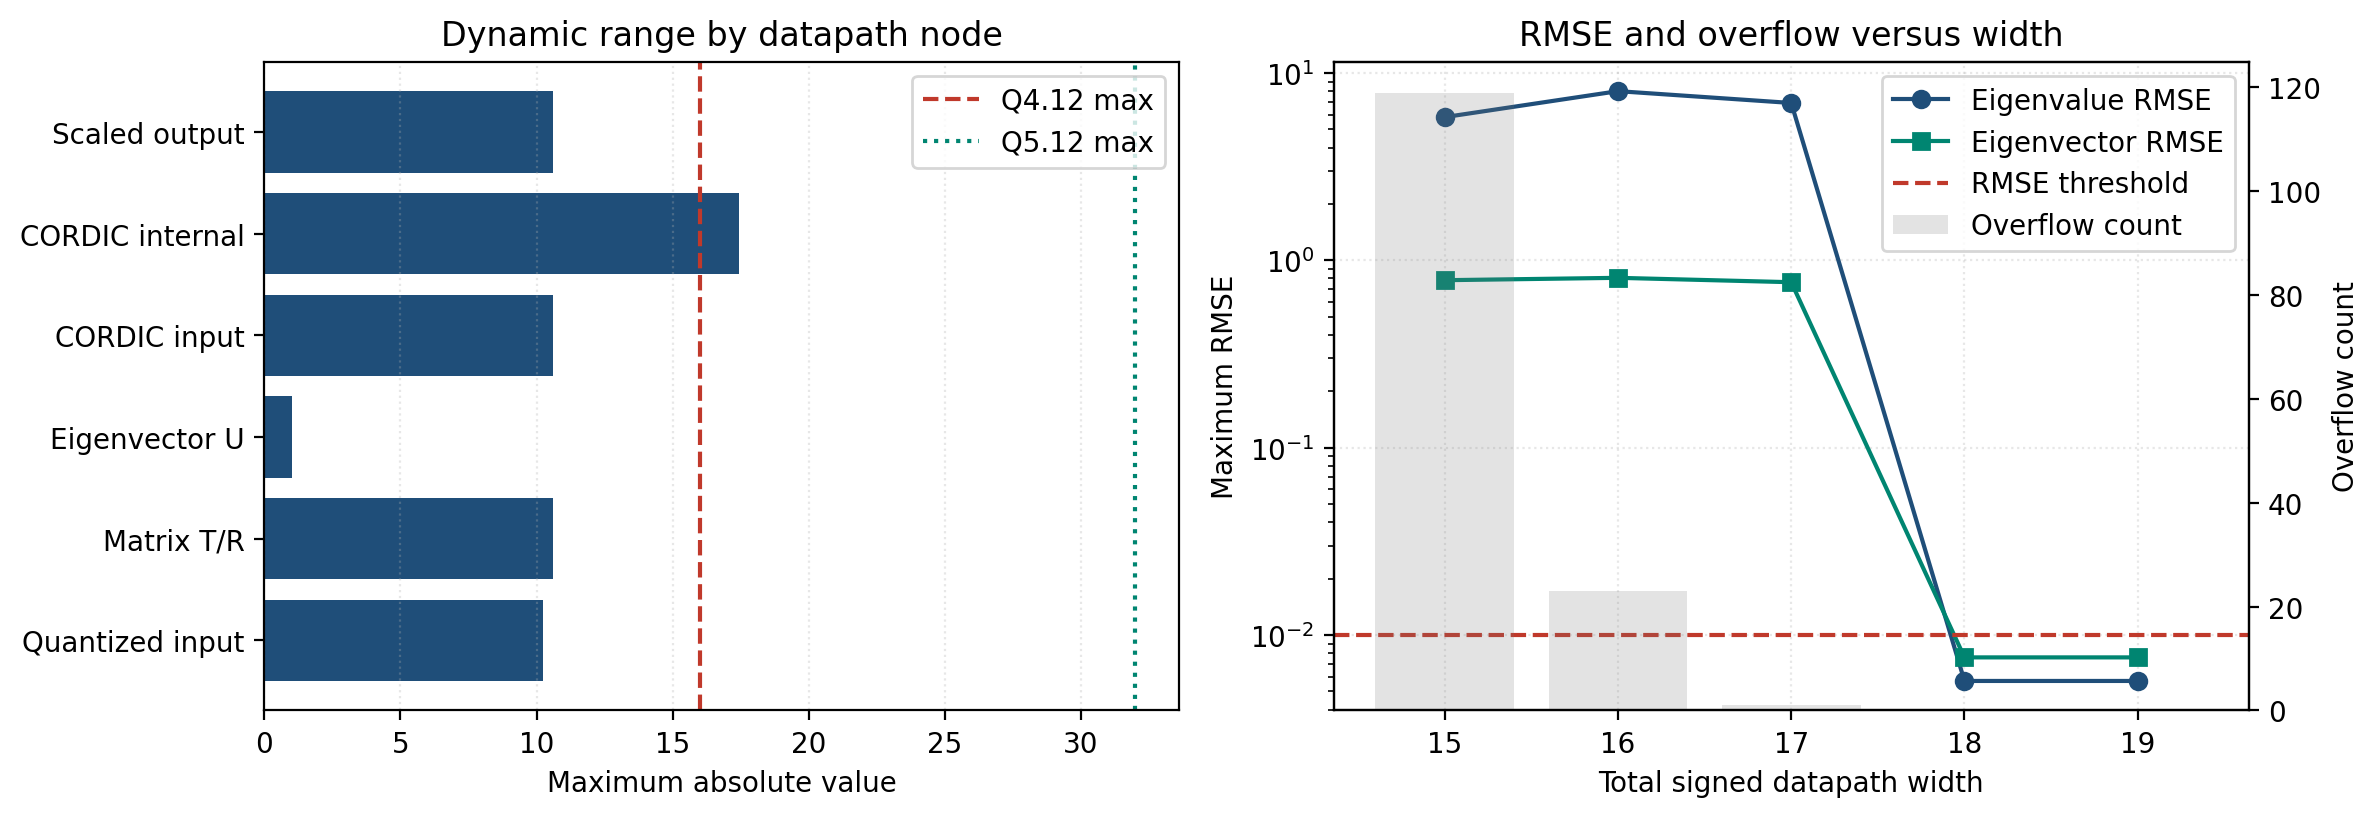

Minimum width: 18 bits, Q5.12
CORDIC peak: 17.434814 at pattern=11, iteration=4, phase=T update, givens=G01, mode=rotation, stage=7
17-bit failure: 1 overflow, 10/11 patterns pass
Minimum integer bits: 5


In [10]:
# Integer Bit-Width Analysis
import pandas as pd
from IPython.display import display

DATA_WIDTH_LIST = range(15, 20)

def required_integer_bits(min_val, max_val, frac_bits):
    lsb = 2.0**(-frac_bits)
    int_bits = 0
    while min_val < -(2.0**int_bits) or max_val > 2.0**int_bits - lsb:
        int_bits += 1
    return int_bits

def format_context(ctx):
    keys = ["pattern", "iteration", "phase", "givens", "mode", "stage", "element"]
    return ", ".join(
        f"{key}={ctx[key]}" for key in keys
        if key in ctx and ctx[key] is not None
    )

# Original Model Check
cfg_ref = EVDConfig(B, N_STAGES, 0.0, MAX_ITER)
rmse_lam_ref, rmse_vec_ref = evaluate_all_patterns(Matrix, cfg_ref)
assert np.array_equal(rmse_lam_ref, rmse_lam)
assert np.array_equal(rmse_vec_ref, rmse_vec)

# Dynamic Range
range_tracker = DynamicRangeTracker()
cfg_range = EVDConfig(B, N_STAGES, 0.0, MAX_ITER, tracker=range_tracker)
evaluate_all_patterns(Matrix, cfg_range)

range_groups = {
    "Quantized input": ["input_quantized"],
    "Matrix T/R": ["matrix_t", "matrix_r"],
    "Eigenvector U": ["eigenvector_u"],
    "CORDIC input": ["cordic_input"],
    "CORDIC internal": ["cordic_internal_raw"],
    "Scaled output": ["cordic_scaled_output"],
}

range_rows = []
for label, names in range_groups.items():
    entry = range_tracker.combine(names)
    int_bits = required_integer_bits(entry["min"], entry["max"], B)
    if abs(entry["min"]) > abs(entry["max"]):
        max_abs = abs(entry["min"])
        max_context = entry["min_context"]
    else:
        max_abs = abs(entry["max"])
        max_context = entry["max_context"]
    range_rows.append({
        "Node": label,
        "Min": entry["min"],
        "Max": entry["max"],
        "Max abs": max_abs,
        "Integer bits": int_bits,
        "Q format": f"Q{int_bits}.{B}",
        "Total bits": 1 + int_bits + B,
        "Worst-case location": format_context(max_context),
    })

range_df = pd.DataFrame(range_rows)
display(range_df.round({"Min": 6, "Max": 6, "Max abs": 6}))

# DATA_WIDTH Sweep
sweep_rows = []
for data_width in DATA_WIDTH_LIST:
    tracker = DynamicRangeTracker()
    cfg = EVDConfig(
        B, N_STAGES, 0.0, MAX_ITER,
        total_bits=data_width, tracker=tracker,
    )
    rmse_lam_w, rmse_vec_w = evaluate_all_patterns(Matrix, cfg)
    pass_mask = (rmse_lam_w < RMSE_THRESH) & (rmse_vec_w < RMSE_THRESH)
    int_bits = data_width - B - 1
    sweep_rows.append({
        "Total bits": data_width,
        "Q format": f"Q{int_bits}.{B}",
        "Overflow count": tracker.overflow_count,
        "Max eigenvalue RMSE": float(np.max(rmse_lam_w)),
        "Max eigenvector RMSE": float(np.max(rmse_vec_w)),
        "Passing patterns": int(np.count_nonzero(pass_mask)),
        "Status": "PASS" if tracker.overflow_count == 0 and np.all(pass_mask) else "FAIL",
        "First overflow": (
            format_context(tracker.first_overflow)
            if tracker.first_overflow is not None else "-"
        ),
    })

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df.round({"Max eigenvalue RMSE": 6, "Max eigenvector RMSE": 6}))

pass_rows = sweep_df[sweep_df["Status"] == "PASS"]
if pass_rows.empty:
    raise RuntimeError("No candidate width satisfies the integer bit requirements.")

min_width = int(pass_rows.iloc[0]["Total bits"])
int_bits = min_width - B - 1
prev_row = sweep_df[sweep_df["Total bits"] == min_width - 1].iloc[0]
cordic_range = range_tracker.ranges["cordic_internal_raw"]
if abs(cordic_range["min"]) > abs(cordic_range["max"]):
    cordic_peak = cordic_range["min"]
    cordic_context = cordic_range["min_context"]
else:
    cordic_peak = cordic_range["max"]
    cordic_context = cordic_range["max_context"]

# Draw the Figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
node_names = range_df["Node"]
axes[0].barh(node_names, range_df["Max abs"], color=C_RMSE_LAM)
prev_int_bits = int_bits - 1
axes[0].axvline(2**prev_int_bits - 2**-B, color=C_RMSE_THRESH, ls="--", label=f"Q{prev_int_bits}.{B} max")
axes[0].axvline(2**int_bits - 2**-B, color=C_RMSE_VEC, ls=":", label=f"Q{int_bits}.{B} max")
axes[0].set_xlabel("Maximum absolute value")
axes[0].set_title("Dynamic range by datapath node")
axes[0].legend()
axes[0].grid(True, axis="x", alpha=0.3, linestyle=":")

widths = sweep_df["Total bits"]
axes[1].plot(widths, sweep_df["Max eigenvalue RMSE"], "o-", color=C_RMSE_LAM, label="Eigenvalue RMSE")
axes[1].plot(widths, sweep_df["Max eigenvector RMSE"], "s-", color=C_RMSE_VEC, label="Eigenvector RMSE")
axes[1].axhline(RMSE_THRESH, color=C_RMSE_THRESH, ls="--", label="RMSE threshold")
axes[1].set_yscale("log")
axes[1].set_xlabel("Total signed datapath width")
axes[1].set_ylabel("Maximum RMSE")
axes[1].set_xticks(widths)
axes[1].set_title("RMSE and overflow versus width")
axes[1].grid(True, alpha=0.3, linestyle=":")
overflow_axis = axes[1].twinx()
overflow_axis.bar(widths, sweep_df["Overflow count"], color="#777777", alpha=0.2, label="Overflow count")
overflow_axis.set_ylabel("Overflow count")
lines, labels = axes[1].get_legend_handles_labels()
bars, bar_labels = overflow_axis.get_legend_handles_labels()
axes[1].legend(lines + bars, labels + bar_labels, loc="upper right")
plt.tight_layout()
plt.show()

print(f"Minimum width: {min_width} bits, Q{int_bits}.{B}")
print(f"CORDIC peak: {cordic_peak:.6f} at {format_context(cordic_context)}")
print(
    f"{min_width - 1}-bit failure: {int(prev_row['Overflow count'])} overflow, "
    f"{int(prev_row['Passing patterns'])}/11 patterns pass"
)
print(f"Minimum integer bits: {int_bits}")